# OU+Threshold: параметрический бейзлайн статьи

Guijarro-Ordonez, Pelger, Zanotti, *Deep Learning Statistical Arbitrage*: Section II.D.1, Appendix B.B, строка «OU+Thresh» в Table I.

Ноутбук показывает, как работает классическая стратегия mean reversion на резидуалах: **резидуал → сигнал OU → позиция → PnL**. Сначала на одном активе, затем на портфеле из ~870 резидуалов, на официальных OOS-резидуалах авторов (CRSP, 1998–2016).

Полные эксперименты (все K, сетка порогов, Avellaneda-Lee, разбивка по годам, синтетика) описаны в `docs/OU_BASELINE.md`, скрипты `scripts/ou_experiments.py` и `scripts/ou_synthetic.py`.

Нужен репозиторий авторов в `references/dlsa-public` (см. README).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dlsa_baseline.data.official_residuals import load_official_residuals
from dlsa_baseline.models.ou import ou_signal, threshold_positions
from dlsa_baseline.training.ou_backtest import OURule, annualized, backtest_ou

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
L, OOS_START = 30, "2002-01-01"
ipca = load_official_residuals("IPCA", 5)
R, dates = ipca.residuals.astype(np.float64), ipca.dates
print(R.shape, dates[0], dates[-1], f"zeros (asset outside universe): {np.mean(R == 0):.0%}")

(4781, 9483) 1998-01-02 2016-12-30 zeros (asset outside universe): 91%


## 1. Модель

Кумулятивный резидуал за последние $L=30$ дней, $X_l=\sum_{j\le l}\epsilon_{t-L+j}$, это «цена» арбитражного портфеля. Считаем его дискретным наблюдением процесса Орнштейна–Уленбека:

$$dX_t=\kappa(\mu-X_t)\,dt+\sigma\,dB_t \quad\Longrightarrow\quad X_{l+1}=a+bX_l+e_l \;\;(\text{AR}(1),\ \Delta t=1\text{ день}).$$

| Параметр | Оценка | Смысл |
|---|---|---|
| $\kappa$ | $-\ln \hat b$ | скорость возврата; период полураспада $\ln 2/\kappa$ дней |
| $\mu$ | $\hat a/(1-\hat b)$ | равновесный уровень («справедливая цена» резидуала) |
| $\sigma/\sqrt{2\kappa}$ | $\sqrt{\hat\sigma_e^2/(1-\hat b^2)}$ | типичное отклонение от $\mu$ в равновесии |
| $R^2$ | корреляция$(X_l, X_{l+1})^2$ | насколько AR(1) вообще описывает окно |

Сигнал $\theta^{OU}=(\kappa,\mu,\sigma/\sqrt{2\kappa},X_L,R^2)$. Правило Avellaneda–Lee (2010) / Yeo–Papanicolaou (2017) работает на s-score $s=(X_L-\mu)/(\sigma/\sqrt{2\kappa})$:

$$w=\begin{cases}-1 & s>c_{thresh},\ R^2>c_{crit} \quad\text{(резидуал «дорогой»: продаём)}\\ +1 & s<-c_{thresh},\ R^2>c_{crit}\quad\text{(«дешёвый»: покупаем)}\\ 0 & \text{иначе}\end{cases}\qquad c_{thresh}=1.25,\ c_{crit}=0.25.$$

Модель валидна только при $0<\hat b<1$ (есть возврат к среднему). Позиция считается по окну $[t-30, t-1]$ и зарабатывает резидуал дня $t$.

## 2. Одно окно: что оценивает модель

asset_81, окно до 2002-05-20
b = 0.742  kappa = 0.299/день  half-life = 2.3 дн.
mu = +0.0414  X_L = +0.0786  sigma_eq = 0.0192  R^2 = 0.44
s = +1.94  ->  позиция -1


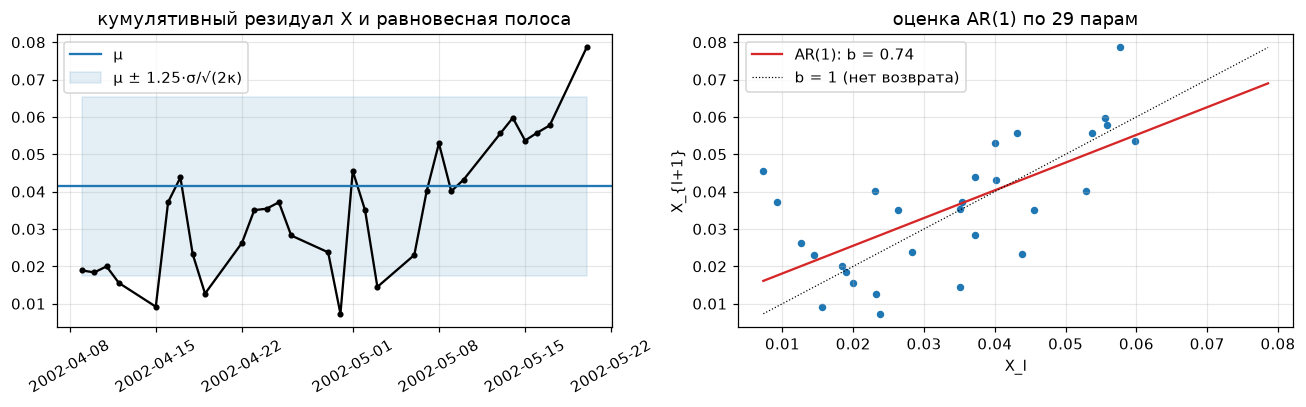

In [2]:
def fit_window(asset, t):
    """OU fit on residuals [t-L, t-1] of one asset."""
    window = R[t - L : t, [asset]]
    signal = ou_signal(window)
    b = float(np.exp(-signal.kappa[0]))
    return window[:, 0], signal, b

asset, t = 81, int(np.searchsorted(dates, np.datetime64("2002-05-21")))
window, sig, b = fit_window(asset, t)
X = np.cumsum(window)
print(f"asset_{asset}, окно до {dates[t - 1]}")
print(f"b = {b:.3f}  kappa = {sig.kappa[0]:.3f}/день  half-life = {np.log(2) / sig.kappa[0]:.1f} дн.")
print(f"mu = {sig.mu[0]:+.4f}  X_L = {sig.last[0]:+.4f}  sigma_eq = {sig.sigma_eq[0]:.4f}  R^2 = {sig.r2[0]:.2f}")
print(f"s = {sig.s_score[0]:+.2f}  ->  позиция {threshold_positions(sig)[0]:+.0f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(dates[t - L : t], X, "k.-")
ax[0].axhline(sig.mu[0], color="C0", label="μ")
ax[0].fill_between(dates[t - L : t], sig.mu[0] - 1.25 * sig.sigma_eq[0], sig.mu[0] + 1.25 * sig.sigma_eq[0],
                   color="C0", alpha=0.12, label="μ ± 1.25·σ/√(2κ)")
ax[0].set_title("кумулятивный резидуал X и равновесная полоса"); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
ax[1].scatter(X[:-1], X[1:], s=15)
grid = np.linspace(X.min(), X.max(), 10)
a = sig.mu[0] * (1 - b)
ax[1].plot(grid, a + b * grid, "C3", label=f"AR(1): b = {b:.2f}")
ax[1].plot(grid, grid, "k:", lw=0.8, label="b = 1 (нет возврата)")
ax[1].set(xlabel="X_l", ylabel="X_{l+1}", title="оценка AR(1) по 29 парам"); ax[1].legend()
plt.tight_layout()

## 3. Путь резидуал → s-score → позиция → PnL на одном активе

Торгуем один резидуал с $w\in\{-1,0,1\}$ (как Fig. A.2 статьи) в течение 30 дней после окна. Первый пример — **тренд, на котором OU проваливается**; второй — колебания, где он работает. Оба найдены скриптом `scripts/ou_experiments.py example`; второй подобран как удачный случай, он не типичный.

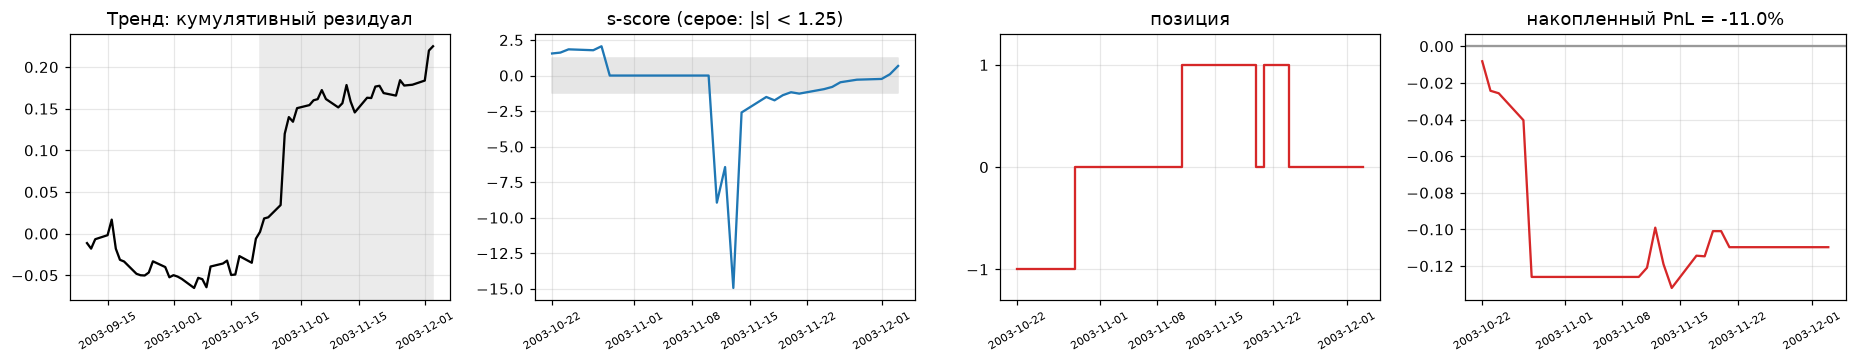

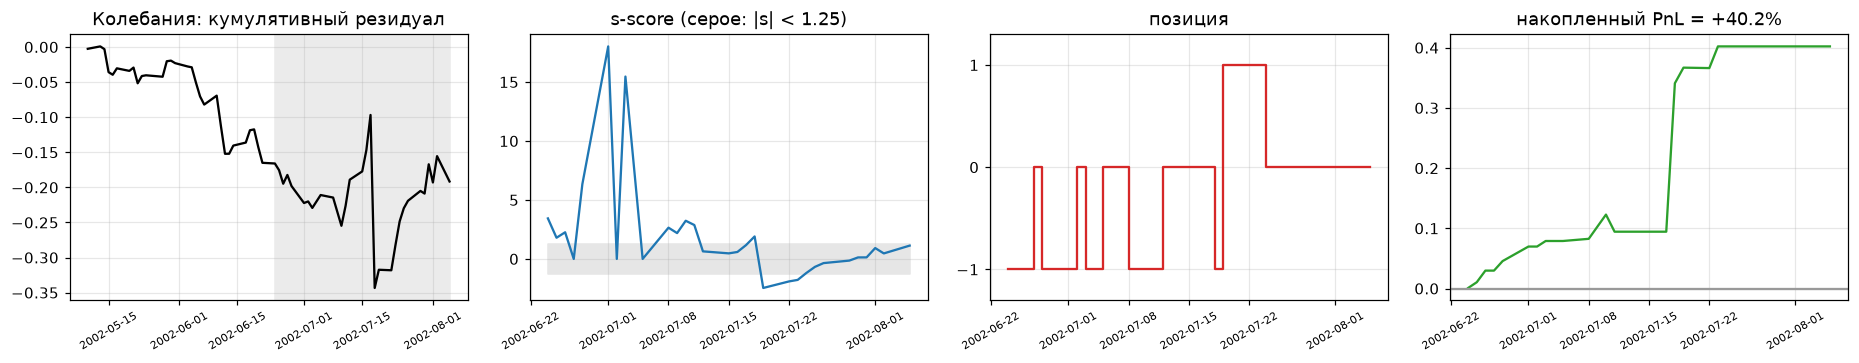

In [3]:
def single_asset(asset, start, horizon=30):
    t0 = int(np.searchsorted(dates, np.datetime64(start)))
    s, w = np.zeros(horizon), np.zeros(horizon)
    for h in range(horizon):
        sig = ou_signal(R[t0 + h - L : t0 + h, [asset]])
        s[h], w[h] = sig.s_score[0], threshold_positions(sig)[0]
    return t0, s, w, w * R[t0 : t0 + horizon, asset]

def four_panels(asset, start, title):
    t0, s, w, pnl = single_asset(asset, start)
    oos, span = dates[t0 : t0 + 30], dates[t0 - L : t0 + 30]
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.4))
    ax[0].plot(span, np.cumsum(R[t0 - L : t0 + 30, asset]), "k"); ax[0].axvspan(oos[0], oos[-1], color="0.92")
    ax[0].set_title(f"{title}: кумулятивный резидуал")
    ax[1].plot(oos, s); ax[1].fill_between(oos, -1.25, 1.25, color="0.9"); ax[1].set_title("s-score (серое: |s| < 1.25)")
    ax[2].step(oos, w, where="post", color="C3"); ax[2].set(ylim=(-1.3, 1.3), yticks=[-1, 0, 1], title="позиция")
    ax[3].plot(oos, np.cumsum(pnl), color="C2" if pnl.sum() > 0 else "C3"); ax[3].axhline(0, color="0.6")
    ax[3].set_title(f"накопленный PnL = {pnl.sum():+.1%}")
    for a in ax: a.tick_params(axis="x", rotation=30, labelsize=7)
    plt.tight_layout()

four_panels(6218, "2003-10-22", "Тренд")
four_panels(1726, "2002-06-24", "Колебания")

**Почему OU проигрывает на тренде.** Модель ставит против последнего движения: на росте s-score уходит вверх и правило шортит. Если у движения есть инерция (моментум), каждая такая ставка убыточна, а когда рост заканчивается, правило успевает перевернуться в лонг на вершине. Одна «скорость» κ и одна равновесная μ не могут описать ни тренд, ни смесь частот; поэтому статья заменяет этот сигнал на CNN+Transformer.

## 4. Портфель: все резидуалы, 2002–2016, против Table I

In [4]:
PAPER = {"FF": 0.38, "PCA": 0.73, "IPCA": 0.97}
results, rows = {}, []
for family in ("FF", "PCA", "IPCA"):
    data = ipca if family == "IPCA" else load_official_residuals(family, 5)
    bt = backtest_ou(data, OURule(), start=OOS_START)
    results[family] = bt
    gross, net = annualized(bt.returns), annualized(bt.net_returns())
    rows.append({"family": family, "SR": gross["SR"], "SR статьи": PAPER[family], "μ": gross["mu"], "σ": gross["sigma"],
                 "SR после издержек": net["SR"], "оборот/день": bt.turnover.mean(),
                 "позиций/день": (bt.n_long + bt.n_short).mean(), "юниверс/день": bt.n_universe.mean()})
formats = {"SR": "{:.2f}", "SR статьи": "{:.2f}", "μ": "{:.1%}", "σ": "{:.1%}", "SR после издержек": "{:.2f}",
           "оборот/день": "{:.2f}", "позиций/день": "{:.0f}", "юниверс/день": "{:.0f}"}
pd.DataFrame(rows).set_index("family").style.format(formats)

,SR,SR статьи,μ,σ,SR после издержек,оборот/день,позиций/день,юниверс/день
family,,,,,,,,
FF,0.34,0.38,1.2%,3.6%,-3.40,0.96,156,869
PCA,0.93,0.73,2.4%,2.6%,-4.16,0.96,156,869
IPCA,0.64,0.97,2.6%,4.1%,-2.68,0.97,154,869


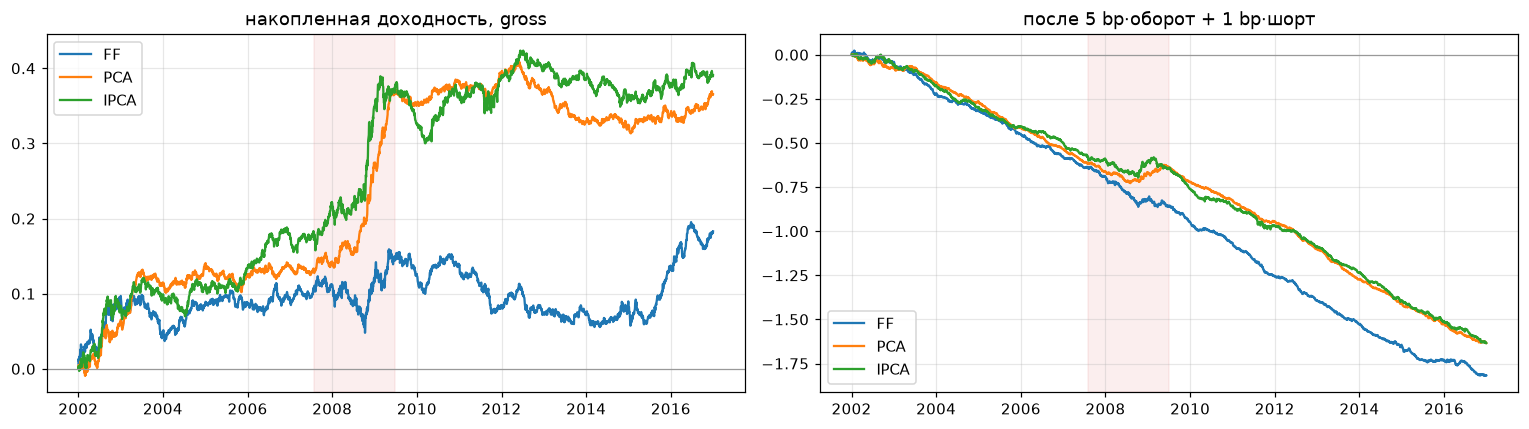

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for family, bt in results.items():
    ax[0].plot(bt.dates, np.cumsum(bt.returns), label=family)
    ax[1].plot(bt.dates, np.cumsum(bt.net_returns()), label=family)
ax[0].set_title("накопленная доходность, gross"); ax[1].set_title("после 5 bp·оборот + 1 bp·шорт")
for a in ax: a.axhline(0, color="0.6", lw=0.8); a.axvspan(np.datetime64("2007-08-01"), np.datetime64("2009-06-30"), color="C3", alpha=0.08); a.legend()
plt.tight_layout()

## 5. Что сказать на защите

1. **Порядок величин воспроизводится.** SR 0.34 / 0.93 / 0.64 против 0.38 / 0.73 / 0.97. Точных цифр не будет: авторы переводят веса в акции через Φ, а Φ не опубликована. Сверка на K=0 (Φ = I) совпадает со статьёй: −0.23 против −0.18.
2. **Φ меняет только дневное плечо.** $\epsilon_t=\Phi_{t-1}R_t$, поэтому PnL авторов равен $w'\epsilon_t/\|\Phi'w\|_1$, наш $w'\epsilon_t/\|w\|_1$: знак каждого дня одинаковый.
3. **PCA > IPCA у нас из-за 2008–2009** (57% PnL PCA). Без кризиса ранжирование статьи восстанавливается: IPCA 0.60 > PCA 0.51 > FF 0.40.
4. **С издержками OU не выживает**: оборот ~1 в день, точка безубыточности ≤ 2 bp. Правило Avellaneda–Lee с гистерезисом вдвое снижает оборот, но не спасает.
5. **Подбором порогов OU не спасти**: лучшая ячейка сетки 1.28 против 3.2–4.2 у CNN+Transformer; фильтр $R^2$ на деле отбирает медленные, трендовые окна ($R^2\approx \hat b^2$).
6. **Независимая сверка**: `experiments/models.py:OUThreshold` Тимура даёт те же позиции (`experiments/test_ou_equivalence.py`), а на его данных (WIKI top-500) SR 0.15 / 0.62 для FF5 / PCA5.